# Training the visual search model, start to finish

This notebook builds, explains, and trains the model that predicts
**where the eyes go first** in visual search — fitted to 114,232
first eye movements from 333 people across 11 published experiments.

**Scope:** the first saccade of each trial, launched from the screen
center. Later saccades need extra machinery (inhibition of return,
moving vantage points) and are out of scope.

**In and out:** a picture of the display, the goal (color + shape),
and the previous trials go in; a probability for every item comes
out. One predicted saccade is one random draw.

**Before running** (needs the public data from https://osf.io/q27ph/):

    python pool_data.py --data_dir ".../Data Files" --out_dir dataset
    python build_contexts.py

Needs numpy, pandas, matplotlib, torch. Training: ~10 minutes.


In [33]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from front_end import render, shape_for, item_positions, IMG
from build_contexts import (shape_match_map, sensory_salience_map,
                            template_match_map, paint_history_footprints)


## 1. Model structure

The fitted model is item-based. For each candidate item $i$, it combines three item-level quantities into one priority value:

$$ F_i = \underbrace{\alpha_P\, P_i}_{\text{sensory evidence}} + \underbrace{g_T\, T_i}_{\text{template evidence}} + \underbrace{\beta_T\, h_{T,i}}_{\text{target history}} $$

- $P_i$: goal-independent bottom-up color salience for item $i$ (§3).
- $T_i$: unified green-circle template evidence for item $i$ (§4), combining signed color match and signed shape match.
- $h_{T,i}$: target-history trace for item slot $i$ (§5).
- Units: $P_i$ and $h_{T,i}$ are in $[0,1]$; $T_i$ is in $[-1,1]$.

The 2-D maps shown in the notebook are visualization/construction aids. They show where item evidence lives on the display, but the fitted model consumes the item table $A[\text{context}, i, \text{field}]$ directly.

**Choice (softmax).** Exponentiate the valid item priorities and divide by their sum. Higher priority means higher probability, but never all of it — that softness is what captures the variability in real eye movements:

$$ \Pr(\text{first saccade} = i) =
\frac{e^{F_i}}{\sum_j e^{F_j}}. $$

**Between trials** target history is a LEAKY ACCUMULATOR: every location fades by $(1-\eta_T)$, and the location the target actually occupied gets a boost of $\eta_T$. So $\eta_T$ is the WEIGHT ON THE MOST RECENT TRIAL: large $\eta_T$ — the last trial or two dominate; small $\eta_T$ — many past trials average together:

$$ h_T \leftarrow (1-\eta_T)\, h_T + \eta_T\, e_T. $$

**Four learned parameters:** $\alpha_P, g_T, \beta_T, \eta_T$.

Two honest notes. (1) A two-color display cannot separate "enhance the target color" from "suppress the distractor color" — only the NET effect is identified — so the template map carries signed color evidence. (2) There is no attention window: with every first-saccade item equally far from fixation, a window would scale all six priorities by the same number, which the gains absorb.


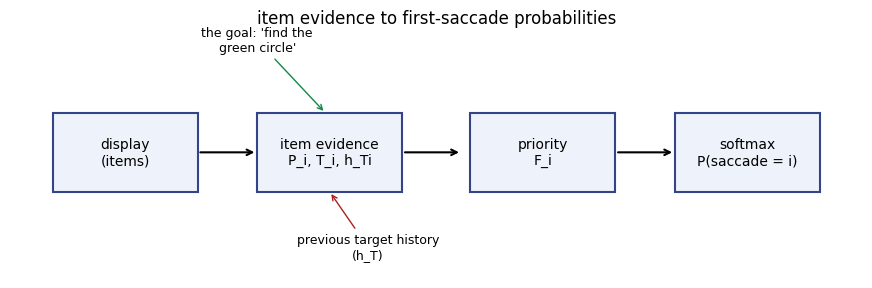

In [34]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.05, "display\n(items)"),
         (0.29, "item evidence\nP_i, T_i, h_Ti"),
         (0.54, "priority\nF_i"),
         (0.78, "softmax\nP(saccade = i)")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.17, 0.32, fc="#eef2fa", ec="#334488", lw=1.5))
    ax.text(x + 0.085, 0.51, label, ha="center", va="center", fontsize=10)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.24, 0.51), xytext=(x + 0.17, 0.51), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'find the\ngreen circle'", xy=(0.37, 0.67), xytext=(0.29, 0.92), ha="center", fontsize=9, arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previous target history\n(h_T)", xy=(0.375, 0.35), xytext=(0.42, 0.08), ha="center", fontsize=9, arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.set_xlim(0, 1.0); ax.set_ylim(0, 1); ax.axis("off")
plt.title("item evidence to first-saccade probabilities")
plt.show()


## 2. The displays: one example per study

Eleven experiments, pooled. Each subject searched one fixed shape
all session, so displays are reconstructed canonically: a CIRCLE
target among mixed other shapes, green items, one red color
singleton. The target never pops out — it is found by shape; the
singleton does pop out. (Each study's own color pair is shown here
for flavor; Hamblin-Frohman ships no color labels, so it falls
back to green/red.)


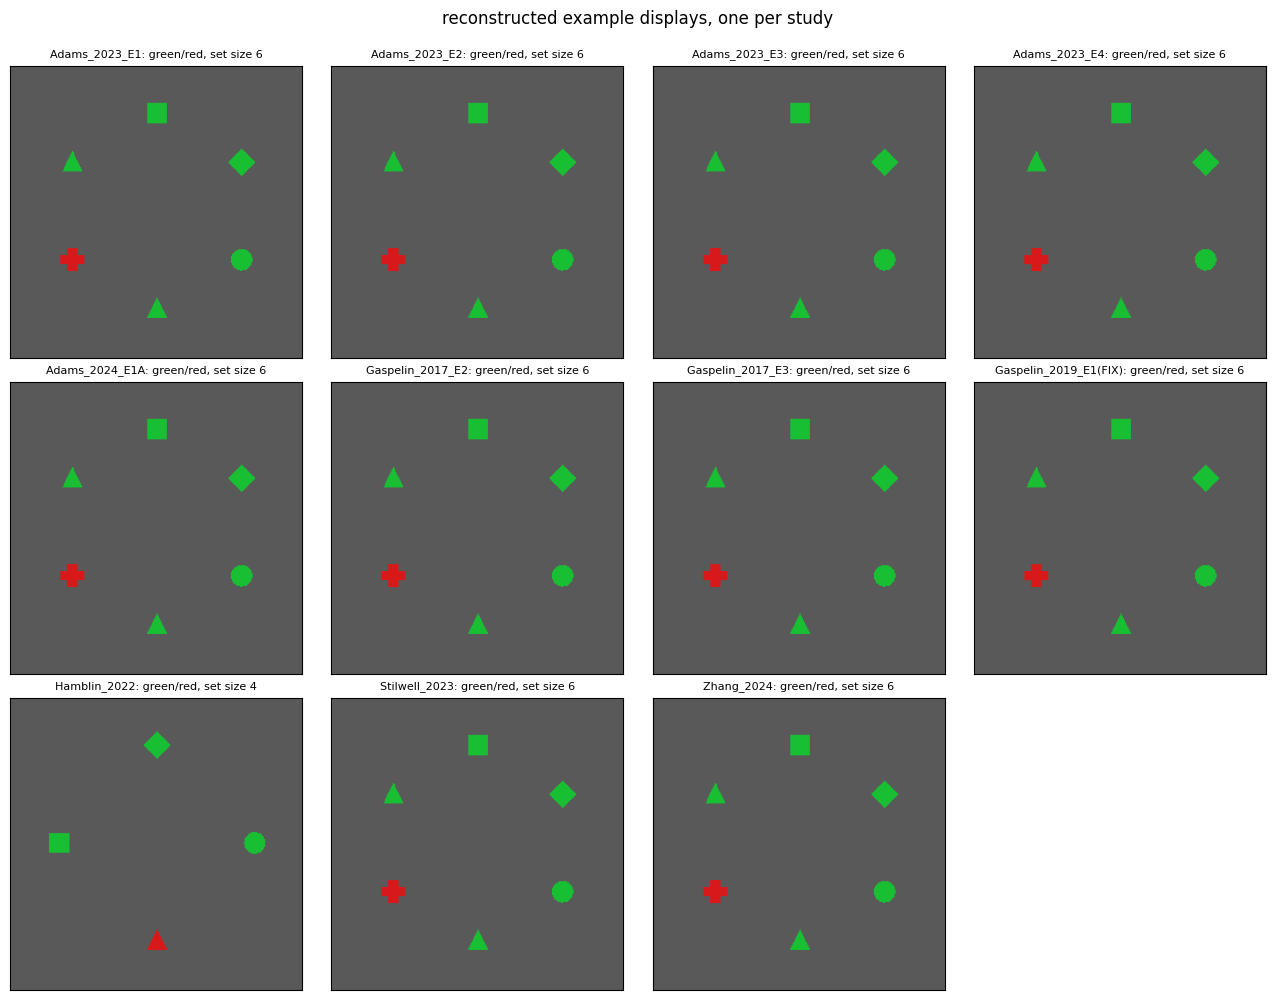

In [35]:
gal = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False,
                  usecols=["study", "setsize", "targCol", "singCol"])
gal = gal[gal.singCol != "none"]

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, (study, sub) in zip(axes.flat, gal.groupby("study")):
    setsize = int(sub.setsize.mode()[0])
    tc, sc = sub[["targCol", "singCol"]].mode().iloc[0]
    ipos, _ = item_positions(setsize)
    tg, sg = 2, (2 + setsize // 2) % setsize + 1   # target & singleton slots
    items = [dict(x=ipos[j][0], y=ipos[j][1],
                  color=sc if (j + 1) == sg else tc,
                  shape=shape_for(j + 1, tg)) for j in range(setsize)]
    ax.imshow(render(items), origin="lower")
    ax.set_title(f"{study}: {tc}/{sc}, set size {setsize}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[gal.study.nunique():]:
    ax.axis("off")
plt.suptitle("reconstructed example displays, one per study", y=0.995)
plt.tight_layout()
plt.show()


## 3. Sensory Evidence

Before the goal can help, the display has to be sensed. The sensory term is goal-independent: it does not know which color or shape is the target. It only says which rendered items are bottom-up color singletons. The background is transparent: it contributes zero sensory evidence.

$$ B_i = lpha_P\,P_i $$

For visualization, we paint each item value into its exact footprint as `P(x)`. The fitted model consumes the item value `P_i` directly. The learned scalar `alpha_P` decides whether this bottom-up salience attracts or suppresses first saccades once template evidence and target history are also in play.


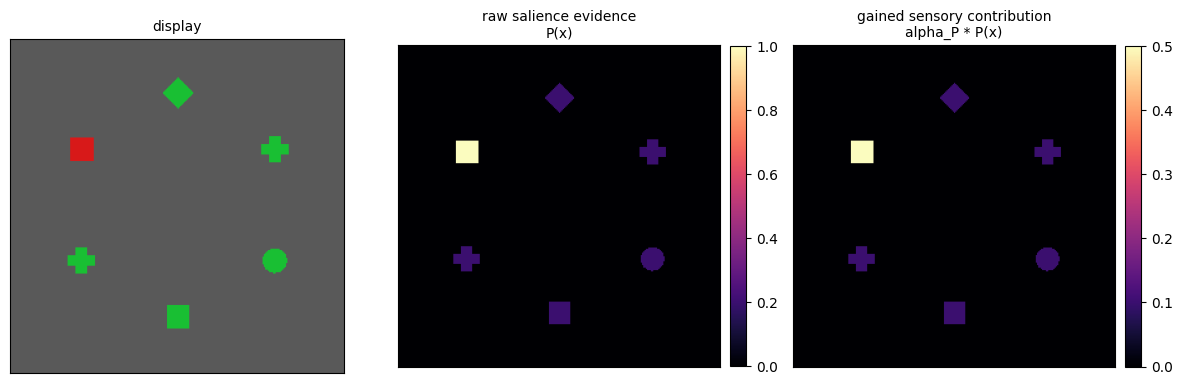

In [36]:

# Canonical display reused through the worked example.
TARG, SING = 1, 4
pos, _ = item_positions(6)
demo_shapes = ["square", "circle", "cross", "diamond", "square", "cross"]
items = [dict(x=pos[j][0], y=pos[j][1],
              color="red" if j == SING else "green",
              shape=demo_shapes[j]) for j in range(6)]
img = render(items)

# Placeholder gain for visualization only; Sec. 8 learns the real value.
alphaP_demo = 0.5
P_map = sensory_salience_map(items)
sensory_field = alphaP_demo * P_map

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(img, origin="lower")
axes[0].set_title("display", fontsize=10)

im0 = axes[1].imshow(P_map, origin="lower", cmap="magma", vmin=0, vmax=1)
axes[1].set_title("raw salience evidence\nP(x)", fontsize=10)

im1 = axes[2].imshow(sensory_field, origin="lower", cmap="magma",
                     vmin=0, vmax=max(float(sensory_field.max()), 1e-9))
axes[2].set_title("gained sensory contribution\nalpha_P * P(x)", fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in [(axes[1], im0), (axes[2], im1)]:
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


## 4. Template Evidence

The goal term scales one unified search-template signal:

$$ G_i = g_T\,T_i $$

`T_i` is signed green-circle template evidence: signed color match and signed shape match are averaged into one item value. A green circle is strongly positive, a red square is strongly negative, and partial matches fall in between. The goal gain does not create this evidence; it only scales evidence already computed from the display.

The gain below is a placeholder; §8 learns the real one. Each panel is scaled to its own range, so compare magnitudes by the color bars.


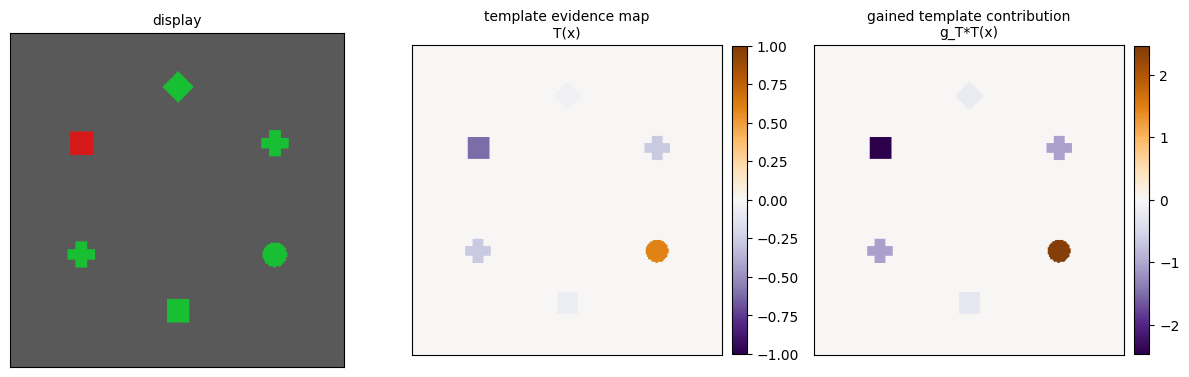

In [37]:
# placeholder goal gain - magnitude picked so the demo map is visible
# (training replaces it with a fitted value)
gT_demo = 4.0

T = template_match_map(items, "green")
goal_field = gT_demo * T

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(img, origin="lower")
axes[0].set_title("display", fontsize=10)

im1 = axes[1].imshow(T, origin="lower", cmap="PuOr_r", vmin=-1, vmax=1)
axes[1].set_title("template evidence map\nT(x)", fontsize=10)

v_goal = max(float(np.abs(goal_field).max()), 1e-9)
im2 = axes[2].imshow(goal_field, origin="lower", cmap="PuOr_r",
                     vmin=-v_goal, vmax=v_goal)
axes[2].set_title("gained template contribution\ng_T*T(x)", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in [(axes[1], im1), (axes[2], im2)]:
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


In the template evidence map, the target is doubly bright: it has the target color and the target shape. Plain green items carry target-color evidence only, and the red singleton is a signed hole. Orange is positive evidence; purple is negative evidence.

Two features of the shape map worth a second look:

- **The circle is a footprint.** Each item receives one shape-similarity score, and that value is painted across the actual object shape for visualization.
- **Similar shapes still count.** The square, cross, and diamond nontargets receive weaker target-shape evidence according to their circle similarity. Color plays no role: the image is binarized before shape matching.


## 5. Location-based Target History

The model remembers where targets have been. There is one number per item location, updated after every trial as a leaky accumulator:

    h_T = (1 - eta_T) * h_T
    h_T[target location] += eta_T

Each entry is a recency-weighted occupancy between 0 and 1, not a probability; nothing normalizes across locations. `eta_T` is the weight on the newest trial: large `eta_T` means recent trials dominate; small `eta_T` means many past trials average together. `beta_T` controls how strongly that learned target-location prior pulls first saccades.

Three panels below:

1. **the accumulator**: `accumulate_history`, replayed over a ten-trial demo history;
2. **the history vector**: one value per item, `beta_T*hT_i`;
3. **the history map**: that vector painted with the actual item-shape footprints. This map is a display aid; the fitted model uses the item vector directly.


h_T: [0.   0.71 0.04 0.24 0.   0.01]  (targets, eta_T = 0.6 )
history vector: [0.00e+00 1.43e+00 7.70e-02 4.80e-01 1.00e-03 1.20e-02]


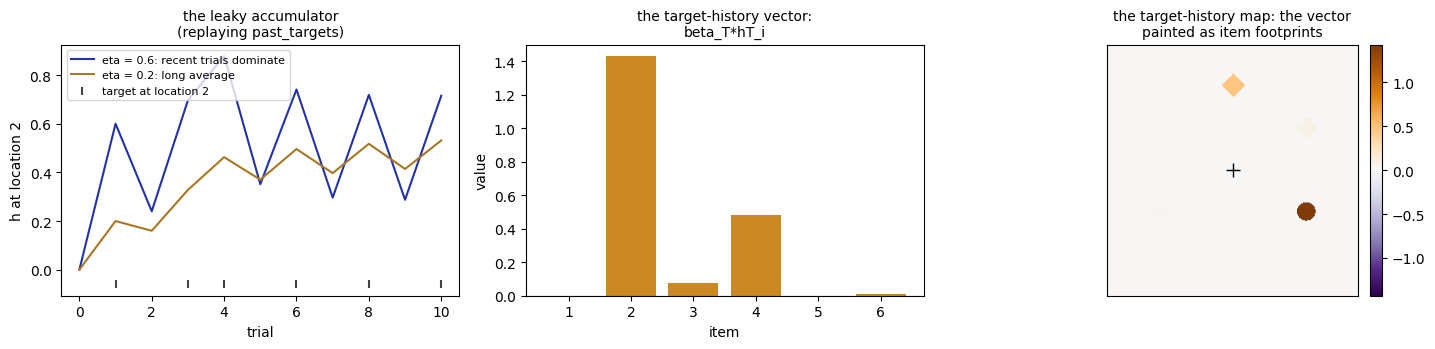

In [38]:
def accumulate_history(past_locs, eta):
    '''The leaky accumulator above, replayed over past trials.
    past_locs: where the item appeared on each previous trial
    (1-6; 0 = absent), oldest first. After each trial everything
    fades by (1 - eta) and that trial's location gets an eta boost.
    (A torch eta makes h a tensor, so Sec. 8's training can take
    gradients through the replay.)'''
    h = torch.zeros(6) if torch.is_tensor(eta) else np.zeros(6)
    for loc in past_locs:
        h = (1 - eta) * h
        if loc:
            h[int(loc) - 1] += eta
    return h

# demo target history, reused all the way to the §7 worked
# example: where the target appeared on the ten previous trials,
# oldest first (1-6 = item location, 0 = absent)
past_targets = [2, 5, 2, 2, 6, 2, 3, 2, 4, 2]   # target favored loc 2
etaT_demo = 0.6                                  # demo memory speed

# replay the SAME target history at two eta values, watch location 2
n_tr = len(past_targets)
h_fast = np.zeros((n_tr + 1, 6)); h_slow = np.zeros((n_tr + 1, 6))
for t in range(n_tr):
    h_fast[t+1] = accumulate_history(past_targets[:t+1], 0.6)
    h_slow[t+1] = accumulate_history(past_targets[:t+1], 0.2)

def selection_history_map(vals, display_items=None):
    # Each patch uses the actual item footprint at that slot, with PEAK
    # HEIGHT 1. A primed square location paints a square, a primed cross
    # location paints a cross, and the target location paints a circle.
    # Torch-ready: with torch vals (Sec. 7) the mask joins them as
    # a tensor so gradients reach beta_T and eta_T.
    these_items = items if display_items is None else display_items
    m = paint_history_footprints(these_items, vals)
    return torch.as_tensor(m) if torch.is_tensor(vals) else m

# the memory after those ten trials, built by the same
# accumulate_history the final model reuses in §7
hT_demo = accumulate_history(past_targets, etaT_demo)
print("h_T:", hT_demo.round(2), " (targets, eta_T =", etaT_demo, ")")
betaT_demo = 2.0      # placeholder gain (near the fitted values)

# ---- the history VECTOR: one number per item location ----
hist_vec = betaT_demo*hT_demo
print("history vector:", hist_vec.round(3))

# ---- the history MAP: the vector painted with the actual item footprints ----
history_map = selection_history_map(hist_vec, items)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
axes[0].plot(h_fast[:, 1], color="#2233aa", label="eta = 0.6: recent trials dominate")
axes[0].plot(h_slow[:, 1], color="#aa7722", label="eta = 0.2: long average")
hit_tr = [t + 1 for t, loc in enumerate(past_targets) if loc == 2]
axes[0].scatter(hit_tr, np.full(len(hit_tr), -0.06),
                marker="|", color="#444444", label="target at location 2")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("h at location 2")
axes[0].set_title("the leaky accumulator\n(replaying past_targets)", fontsize=10)
axes[0].legend(fontsize=8)
cols = ["#cc8822" if v_ >= 0 else "#553388" for v_ in hist_vec]
axes[1].bar(range(1, 7), hist_vec, color=cols)
axes[1].axhline(0, color="#999999", lw=0.8)
axes[1].set_xlabel("item"); axes[1].set_ylabel("value")
axes[1].set_title("the target-history vector:\n"
                  "beta_T*hT_i", fontsize=10)
v = np.abs(history_map).max()
im_p = axes[2].imshow(history_map, origin="lower", cmap="PuOr_r",
                      vmin=-v, vmax=v)
axes[2].plot(IMG/2, IMG/2, "k+", ms=10)
axes[2].set_title("the target-history map: the vector\npainted as item footprints", fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im_p, ax=axes[2], fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


## 6. Combining Item Evidence Into Priorities

The fitted model is item-based: sensory evidence (§3), template evidence (§4), and target history (§5) are combined once per candidate item. The 2-D maps in this section are visual displays of those ingredients, not the object optimized by the fitted model.

    F_i = alpha_P*P_i + g_T*T_i + beta_T*h_Ti


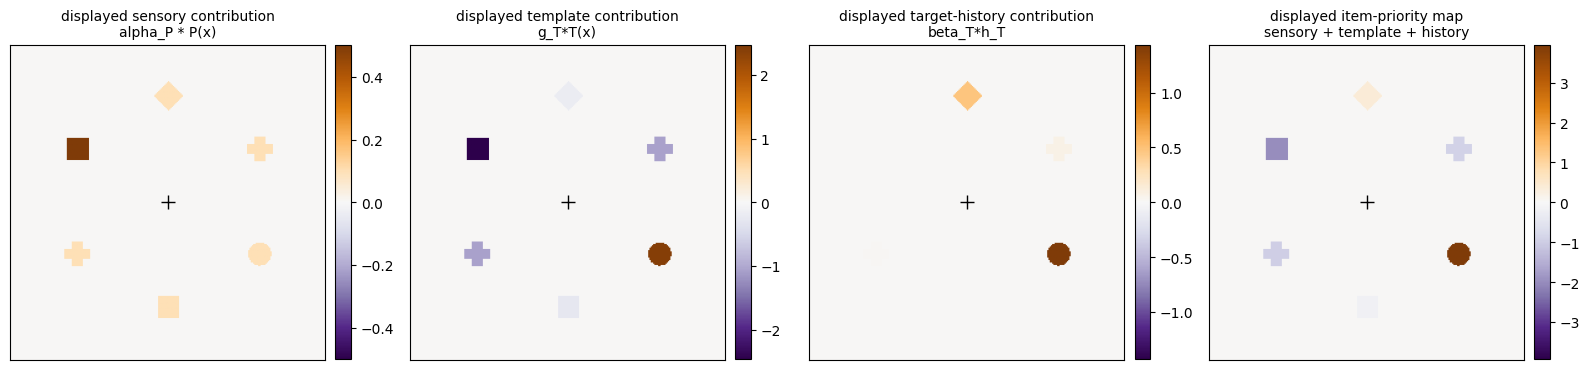

In [39]:

priority_map_demo = sensory_field + goal_field + history_map

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
plots = [
    (sensory_field, "displayed sensory contribution\nalpha_P * P(x)"),
    (goal_field, "displayed template contribution\ng_T*T(x)"),
    (history_map, "displayed target-history contribution\nbeta_T*h_T"),
    (priority_map_demo, "displayed item-priority map\nsensory + template + history"),
]
for ax, (m, ttl) in zip(axes, plots):
    v = max(np.abs(m).max(), 1e-9)
    im = ax.imshow(m, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
    ax.plot(IMG/2, IMG/2, "k+", ms=10)
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


## 7. Worked Example: Raw Display to Prediction

The two helper functions below are the tutorial route through the model:

1. **`priority_map`** (§3-6): paint sensory evidence, template evidence, and target history onto the display so we can inspect them;
2. **`predict_saccade`** (§1): read one priority per item and softmax those six values into `P(first saccade)`.

The fitted training loop in §8 skips the pixels and uses the same item values directly. The learned parameters are the four from §1: `alpha_P`, `g_T`, `beta_T`, and `eta_T`.


In [40]:
# accumulate_history and selection_history_map are §5 helpers - reused, not redefined

def priority_map(img, past_targets,
                 alpha_P, g_T, beta_T, eta_T,
                 target_color="green", display_items=None):
    '''Tutorial visualization route from raw display inputs.

    The fitted model is item-based, but this helper paints the same
    sensory evidence, template evidence, and target-history vector into
    display maps so the intermediate fields can be inspected.'''
    pmap = sensory_salience_map(display_items if display_items is not None else items)
    t_map = template_match_map(display_items if display_items is not None else items,
                               target_color)                 # template evidence

    # Fixed maps become tensors here, where they meet learned gains.
    pmap = torch.as_tensor(pmap)
    t_map = torch.as_tensor(t_map)
    sensory_field = alpha_P * pmap
    goal_field = g_T * t_map

    h_T = accumulate_history(past_targets, eta_T)        # §5
    history_field = selection_history_map(beta_T*h_T, display_items if display_items is not None else items)
    return sensory_field + goal_field + torch.as_tensor(history_field)


def predict_saccade(pm):
    '''Read one priority per item from the displayed map, then softmax.

    This mirrors the item model for the worked example; §8 uses the
    cached item values directly.'''
    pm = torch.as_tensor(pm)      # keeps gradients when pm carries them
    priorities = []
    for j_ in range(6):
        px_ = int(round((pos[j_][0] + 0.75) / 1.5 * IMG))
        py_ = int(round((pos[j_][1] + 0.75) / 1.5 * IMG))
        priorities.append(pm[py_, px_])
    F_ = torch.stack(priorities).float()[None]
    return torch.softmax(F_, 1), F_

print("the tutorial route: priority_map -> predict_saccade")


the tutorial route: priority_map -> predict_saccade


### One worked example, raw image to prediction

The §3-4 display fields and the §5 histories go in with placeholder
weights; out come the map, the six sensed priorities, and the
prediction. (With these placeholder gains the history bump at
item 2 dominates; §7 learns the real balance.)


priority per item: [-0.26  3.83 -1.    0.3  -2.47 -1.06]
P(first saccade):  [ 1.6 94.   0.8  2.7  0.2  0.7] %
most likely saccade: item 2 (the target; one PREDICTED saccade = one draw from these)


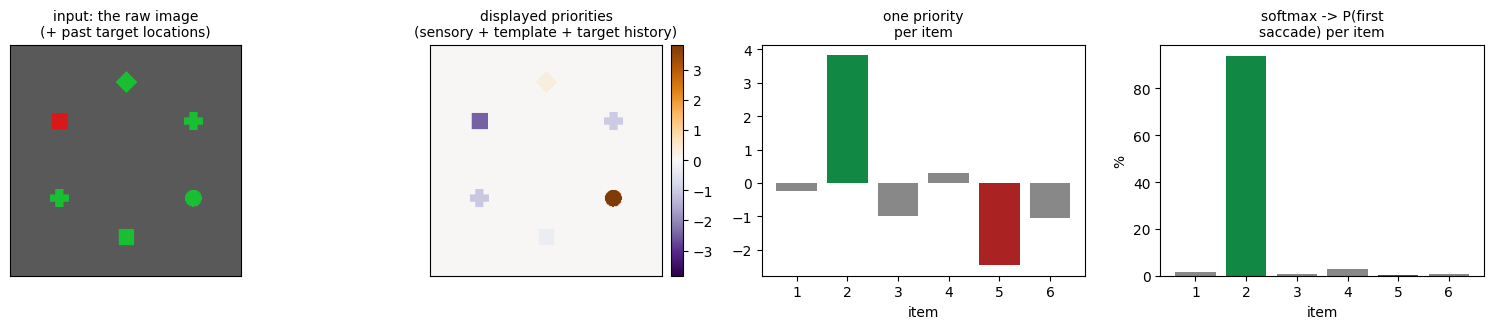

In [41]:
# the four Sec. 1 parameters, in one place
PARAMS = dict(alpha_P=0.0, g_T=gT_demo,
              beta_T=betaT_demo, eta_T=etaT_demo)

pm = priority_map(img, past_targets, **PARAMS)
p_ex, F_ex = predict_saccade(pm)

print("priority per item:", F_ex[0].numpy().round(2))
print("P(first saccade): ", (p_ex[0].numpy() * 100).round(1), "%")
print("most likely saccade: item", int(F_ex[0].argmax()) + 1,
      "(the target; one PREDICTED saccade = one draw from these)")

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.4))
axes[0].imshow(img, origin="lower")
axes[0].set_title("input: the raw image\n(+ past target locations)", fontsize=10)
pm_np = np.asarray(pm)
v = np.abs(pm_np).max()
im = axes[1].imshow(pm_np, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[1].set_title("displayed priorities\n(sensory + template + target history)", fontsize=10)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.03)
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])
cols = ["#888888"] * 6
cols[TARG], cols[SING] = "#118844", "#aa2222"
axes[2].bar(range(1, 7), F_ex[0].numpy(), color=cols)
axes[2].set_title("one priority\nper item", fontsize=10)
axes[2].set_xlabel("item")
axes[3].bar(range(1, 7), p_ex[0].numpy() * 100, color=cols)
axes[3].set_title("softmax -> P(first\nsaccade) per item", fontsize=10)
axes[3].set_xlabel("item"); axes[3].set_ylabel("%")
plt.tight_layout()
plt.show()


## 8. Train on the actual data

The dataset holds every first saccade from 333 people, plus the full trial order needed to rebuild each person's target-history trace. Excluded at pooling (`pool_data.py`): trials with motion/onset singletons, and Stilwell's low-salience trials. The low-salience trials stay outside fitting and become the counterfactual-style test in §9b.

We hold out 20% of the people and fit by maximum likelihood: replay everyone's trials, score the probability the model gave the real eye movement, and nudge the four parameters by gradient descent.

**Why not call `priority_map()` directly in the loop?** It works as a teaching route, but the fitted model is item-based. Pixel maps would repeatedly repaint the same displays without changing the likelihood. So we cache what the parameters never touch: per display, the three item fields at each candidate item, plus the trial-ordered target-history trace. Each epoch reassembles the six item priorities with the current parameters. Nothing is approximated; the next cell checks the map route against the item cache on one trial.


In [42]:

# build the exact item cache used by the fitted model
import data

sacc = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False)  # a row per first saccade
ev = pd.read_csv("dataset/events.csv", low_memory=False)          # a row per trial
sacc, tt = data.build_tensors(sacc, ev)   # a few minutes: aligns everything
N = len(sacc)

def items_for(setsize, targ, sing, tc="green", sc="red"):
    ipos, _ = item_positions(setsize)
    return [dict(x=ipos[j][0], y=ipos[j][1],
                 color=(sc if j + 1 == sing else tc),
                 shape=shape_for(j + 1, targ)) for j in range(setsize)]

def display_for(setsize, targ, sing, tc="green", sc="red"):
    '''Re-render a display from its trial parameters (Sec. 2/3).'''
    return render(items_for(setsize, targ, sing, tc, sc))

def channel_maps(img_, items_, tc="green"):
    # Model-facing item fields: P, T, S_T diagnostic.
    pmap = sensory_salience_map(items_)
    t_map = template_match_map(items_, tc)
    s_t = shape_match_map(img_)
    return torch.stack([torch.as_tensor(pmap),
                        torch.as_tensor(t_map),
                        torch.as_tensor(s_t)])

def centers(setsize):
    # display-map readout helper for the §7 sanity check
    ipos, _ = item_positions(setsize)
    return [(int(round((p[1]+0.75)/1.5*IMG)), int(round((p[0]+0.75)/1.5*IMG)))
            for p in ipos]

# every display any saccade saw, sensed: A_CH[display, item, field]
keys = sorted(set(zip(sacc.setsize.astype(int),
                      sacc.targLoc.astype(int), sacc.singLoc.astype(int))))
A_CH = torch.zeros(len(keys), 6, 3)
for d_, key in enumerate(keys):
    items_ = items_for(*key)
    ch = channel_maps(display_for(*key), items_)
    for j_, (py_, px_) in enumerate(centers(key[0])):
        A_CH[d_, j_] = ch[:, py_, px_].float()
# no extra unit step: the fields are greyscale (Sec. 3), so the
# cached values already ARE the model's units
DIDX = {key: i for i, key in enumerate(keys)}
didx = torch.tensor([DIDX[key] for key in
                     zip(sacc.setsize.astype(int), sacc.targLoc.astype(int),
                         sacc.singLoc.astype(int))])

n_subj = tt["eT"].shape[0]
rng = np.random.default_rng(0)
test_subj = torch.zeros(n_subj, dtype=torch.bool)
test_subj[rng.choice(n_subj, n_subj // 5, replace=False)] = True
test = test_subj[tt["si"]]; train = ~test
print(f"{N} saccades, {len(keys)} displays sensed "
      f"({A_CH.numel()} cached numbers); "
      f"{int((~test_subj).sum())} people to train on, "
      f"{int(test_subj.sum())} held out")


114232 saccades, 52 displays sensed (936 cached numbers); 267 people to train on, 66 held out


**Sanity check.** One trial through both routes with the same parameters: the visual `priority_map()` -> `predict_saccade()` route, and the cached item reassembly used for training. The six priorities must agree to float precision.


In [43]:
def cached_F(key, h_T, alpha_P, g_T, beta_T):
    # reassemble the six item priorities from cached pieces
    s_ = key[0]
    items_ = items_for(*key)
    ch = channel_maps(display_for(*key), items_)
    vals = torch.as_tensor(beta_T*h_T)  # literal target-history model
    F_ = []
    for i_, (py_, px_) in enumerate(centers(s_)):
        stim = alpha_P*ch[0, py_, px_] + g_T*ch[1, py_, px_]
        F_.append(stim + vals[i_])
    return torch.stack(F_)

pt = past_targets          # the Sec. 5 demo target history
key0 = (6, 1, 4)                      # target slot 1, singleton slot 4
F_lit = predict_saccade(priority_map(display_for(*key0), pt, **PARAMS,
                                      display_items=items_for(*key0)))[1][0]
F_c = cached_F(key0,
               accumulate_history(pt, PARAMS["eta_T"]),
               PARAMS["alpha_P"], PARAMS["g_T"],
               PARAMS["beta_T"])
print("literal:", F_lit.numpy().round(6))
print("cached: ", F_c.float().numpy().round(6))
print(f"max |difference|: {float((F_lit - F_c.float()).abs().max()):.2e}")


literal: [ 2.4       0.35323  -0.107026 -1.987222 -1.599214 -1.064398]
cached:  [ 2.4       0.35323  -0.107026 -1.987222 -1.599214 -1.064398]
max |difference|: 0.00e+00


### The fit, at scale

Per epoch: replay the target memories (because `eta_T` is learning) and reassemble every saccade's six priorities from the cached item values. Set-size-4 displays (Hamblin 2022) use four valid item rows. No unit bookkeeping: the item fields are already in the model's units.


epoch 0: loss 1.5860
epoch 25: loss 1.4661
epoch 50: loss 1.4634
epoch 75: loss 1.4622
epoch 100: loss 1.4618
epoch 125: loss 1.4617
epoch 150: loss 1.4617
epoch 175: loss 1.4617
epoch 200: loss 1.4617
epoch 225: loss 1.4617
epoch 250: loss 1.4617
epoch 275: loss 1.4617


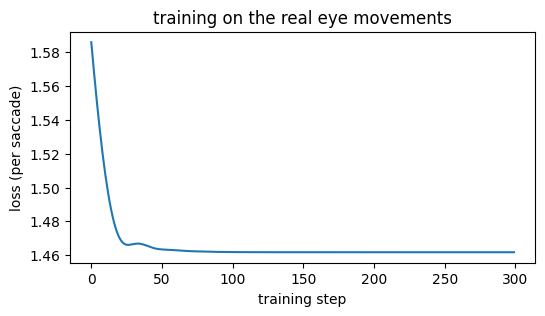

In [44]:
def build_memories(eta_T):
    # replay every subject's trials in order; memory AS OF each trial
    S_, T_, _ = tt["eT"].shape
    hT = torch.zeros(S_, 6)
    outT = []
    for t in range(T_):
        outT.append(hT)
        hT = (1 - eta_T) * hT + eta_T * tt["eT"][:, t]
    return torch.stack(outT, 1)

def model_F(w, raw_eta, A_=None):
    """Every saccade's six item priorities: the Sec. 7 model
    reassembled from the item cache. Between epochs only the target
    memories are recomputed; the gains just reweigh cached numbers.
    A_ substitutes alternative item fields for the same trials
    (Sec. 10b's counterfactual displays); default: the real ones."""
    eta_T = torch.sigmoid(raw_eta["T"])
    memT = build_memories(eta_T)
    hT = memT[tt["si"], tt["ti"]]
    Ad = (A_CH if A_ is None else A_)[didx]        # item fields: P, T, S_T diagnostic
    g_T = torch.nn.functional.softplus(w["raw_g_T"])
    stimulus = w["alpha_P"]*Ad[..., 0] + g_T*Ad[..., 1]
    F = stimulus + w["beta_T"] * hT
    return F, memT

w = {name: torch.tensor(v, requires_grad=True) for name, v in
     [("alpha_P", 0.0), ("raw_g_T", 0.0),
      ("beta_T", 0.5)]}
raw_eta = {"T": torch.tensor(0.0, requires_grad=True)}
optimizer = torch.optim.Adam(list(w.values()) + list(raw_eta.values()), lr=0.05)

losses = []
for epoch in range(300):
    F, _ = model_F(w, raw_eta)
    F = F.masked_fill(~tt["valid"], -1e9)
    logp = torch.log_softmax(F, 1).gather(
        1, tt["choice"][:, None]).squeeze(1)
    loss = -logp[train].mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if epoch % 25 == 0:
        print(f"epoch {epoch}: loss {loss.item():.4f}", flush=True)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("training step"); plt.ylabel("loss (per saccade)")
plt.title("training on the real eye movements")
plt.show()


In [45]:
learned = {k: v.item() for k, v in w.items() if k != "raw_g_T"}
learned["g_T"] = torch.nn.functional.softplus(w["raw_g_T"]).item()
learned["eta_T"] = torch.sigmoid(raw_eta["T"]).item()

for name, meaning in [
        ("alpha_P", "bottom-up sensory color salience"),
        ("g_T", "modulates green-circle template match"),
        ("beta_T", "pull toward past target locations"),
        ("eta_T", "weight on recent target locations")]:
    print(f"{name:8} = {learned[name]:+7.3f}   {meaning}")


alpha_P  =  -0.050   bottom-up sensory color salience
g_T      =  +1.339   modulates green-circle template match
beta_T   =  +2.092   pull toward past target locations
eta_T    =  +0.588   weight on recent target locations


## 9. Evaluation: how good is it? (held-out people only)

Scored ONLY on people the model never saw. Three measures:

- **Mean probability on the true choice** — the geometric-mean
  probability the model assigned to the item actually fixated.
  Chance: 1/(items on screen), ~18% here.
- **Top-1 accuracy** — how often the actual choice was the model's
  highest-probability item. Chance ~18%.
- **Pseudo-R-squared** — `1 - NLL_model / NLL_chance`. 0 = no
  better than guessing; 1 = perfect. For human choice data,
  0.2-0.4 counts as excellent — the same person, display, and
  history does not always yield the same saccade, so 1.0 is
  unreachable in principle.


In [46]:

with torch.no_grad():
    F, memT = model_F(w, raw_eta)
    F = F.masked_fill(~tt["valid"], -1e9)
    prob = torch.softmax(F, 1)
    p_true = prob.gather(1, tt["choice"][:, None]).squeeze(1)

nll = -p_true[test].log().mean()
chance = torch.log(tt["valid"].sum(1).float())[test].mean()
print(f"held-out saccades: {int(test.sum())}")
print(f"mean probability on the true choice: "
      f"{p_true[test].log().mean().exp()*100:.1f}%  "
      f"(chance {torch.exp(-chance)*100:.1f}%)")
print(f"top-1 accuracy: "
      f"{(prob.argmax(1) == tt['choice'])[test].float().mean()*100:.1f}%")
print(f"pseudo-R-squared vs chance: {1 - nll/chance:.3f}")
print(f"held-out NLL per saccade: {nll:.5f}")


held-out saccades: 23216
mean probability on the true choice: 24.6%  (chance 17.4%)
top-1 accuracy: 44.3%
pseudo-R-squared vs chance: 0.197
held-out NLL per saccade: 1.40365


**Interpretation.** The model roughly halves a stranger's
first-saccade uncertainty: ~25% geometric-mean probability on the
true choice vs ~18% chance, the right item as top guess almost
half the time, pseudo-R-squared ~0.2. For calibration:
memorization benchmarks built from the training people (choice
frequencies per display, even per person) score WORSE — the graded
history traces carry information no frequency table can (RESULTS,
"Oracle benchmarks").


### 9a. Oculomotor suppression

Held-out people only; nothing below was fitted to these patterns —
they fall out of the one trained equation. First saccades go to the
salient red singleton LESS often than to an average plain item — the
below-baseline suppression this dataset exists to measure.


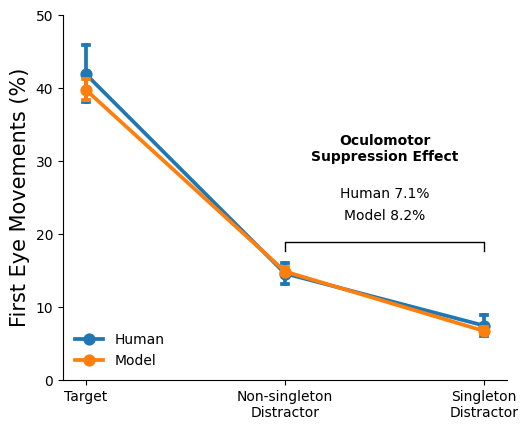

Human: non-singleton vs singleton distractor (paired across 66 held-out subjects)
      T  dof alternative  p_val         CI95  cohen_d  power      BF10
10.7883   65   two-sided    0.0 [5.82, 8.47]   1.2096    1.0 1.599e+13 

Model: non-singleton vs singleton distractor (paired across 66 held-out subjects)
     T  dof alternative  p_val         CI95  cohen_d  power      BF10
23.352   65   two-sided    0.0 [7.46, 8.86]    3.676    1.0 1.009e+30 



In [53]:
first = torch.tensor((sacc.saccindex == 1).values)  # all True: the scope
sing_present = torch.tensor((sacc.singLoc > 0).values)
rows = torch.arange(N)
isT = torch.zeros(N, 6); isT[rows, torch.tensor(sacc.targLoc.values) - 1] = 1
isS = torch.zeros(N, 6)
sp = torch.tensor(sacc.singLoc.values)
isS[rows[sp > 0], sp[sp > 0] - 1] = 1
chose = torch.zeros(N, 6); chose[rows, tt["choice"]] = 1

m = test & first & sing_present

# REGENERATE the test saccades: one model saccade per real trial,
# drawn from the predicted probabilities (each trial conditioned on
# the subject's actual history). The model line then carries the
# same trial-count binomial noise as the people line, so its error
# bars and t-test are commensurable with the data's.
gen = torch.Generator().manual_seed(0)
sim = torch.multinomial(prob[m], 1, generator=gen).squeeze(1)
simch = torch.zeros(int(m.sum()), 6)
simch[torch.arange(int(m.sum())), sim] = 1

def subject_rates(ch_):
    """One set of saccades (0/1 choice rows over mask m) -> each
    held-out subject's landing rates (%): columns t (target),
    ns (plain-item average), s (singleton)."""
    d_ = pd.DataFrame(dict(
        si=tt["si"][m].numpy(),
        t=(ch_ * isT[m]).sum(1).numpy(),
        s=(ch_ * isS[m]).sum(1).numpy(),
        n_pl=(tt["valid"][m].sum(1).float() - 2).clamp(min=1).numpy()))
    d_["ns"] = (1 - d_.t - d_.s) / d_.n_pl
    return d_.drop(columns="n_pl").groupby("si").mean() * 100

def rates_long(frames_, cond_name):
    """{condition: subject_rates frame} -> long form for seaborn:
    one row per subject x condition x item type."""
    cat = pd.concat([fr[["t", "ns", "s"]].reset_index().assign(**{cond_name: k})
                     for k, fr in frames_.items()])
    return cat.melt(id_vars=["si", cond_name], var_name="item",
                    value_name="rate")

frames = {"Human": subject_rates(chose[m]), "Model": subject_rates(simch)}

# the suppression effect (non-singleton minus singleton), tested
# separately per line: paired t-test across subjects
import pingouin as pg
tests = {src_: pg.ttest(fr["ns"], fr["s"], paired=True)
         for src_, fr in frames.items()}

def p_str(t_):
    p = t_["p_val"].iloc[0]
    return "p < .001" if p < .001 else f"p = {p:.3f}"

# seaborn does the means and the bootstrapped 95% CIs (over the
# subject-level rows) itself
import seaborn as sns
fig9a, ax = plt.subplots(figsize=(5.4, 4.4))
ax = sns.pointplot(data=rates_long(frames, "source"), x="item", y="rate",
                   hue="source", order=["t", "ns", "s"],
                   hue_order=["Human", "Model"],
                   errorbar=("ci", 95), n_boot=10000, seed=0, capsize=0.03)
supp = {src_: fr["ns"].mean() - fr["s"].mean() for src_, fr in frames.items()}
top = max(fr["ns"].mean() for fr in frames.values()) + 4
ax.plot([1, 1, 2, 2], [top - 1.2, top, top, top - 1.2], "k-", lw=1)
ax.text(1.5, 30, "Oculomotor\nSuppression Effect", ha="center", fontsize=10, fontweight="bold")
ax.text(1.5, 25, f"Human {supp['Human']:.1f}%", ha="center", fontsize=10)
ax.text(1.5, 22, f"Model {supp['Model']:.1f}%", ha="center", fontsize=10)
ax.set_xticks([0, 1, 2], ["Target", "Non-singleton\nDistractor", "Singleton\nDistractor"])
ax.set_xlabel(""); ax.set_ylabel("First Eye Movements (%)", fontsize=15)
ax.set_ylim(0, 50)
ax.legend(loc="lower left", frameon=False, title=None, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for src_ in ("Human", "Model"):
    print(f"{src_}: non-singleton vs singleton distractor "
          f"(paired across {len(frames[src_])} held-out subjects)")
    print(tests[src_].round(4).to_string(index=False), "\n")


### 9b. High- vs low-salience suppression (Stilwell)
Stilwell (2023) found MORE suppression for MORE salient singletons. A
strong test: the low-salience trials were excluded from our data
entirely (§8) — the model has never seen them. We apply the
trained weights, unchanged, to displays rendered in the pipeline's
schematic colors (a red vs a less-red family; the claim is the
qualitative gradient, not Stilwell's exact colors or numbers).

(Design: the real held-out trials ARE the high-salience
condition — green target, red singleton. We run one counterfactual
second pass over the SAME trials with the singleton re-rendered in
teal (near the target color = low salience), keeping each
subject's real selection history, and regenerate saccades from
both passes. One line per condition, all three item types; the
suppression difference is the salience x item-type interaction in
a repeated-measures ANOVA over the held-out subjects. For
reference, people show the same gradient: 7.0% vs 11.3% first
saccades to the singleton — from the full battery over all of
Stilwell's color pairs, the raw low-salience files are
not in the repo.)


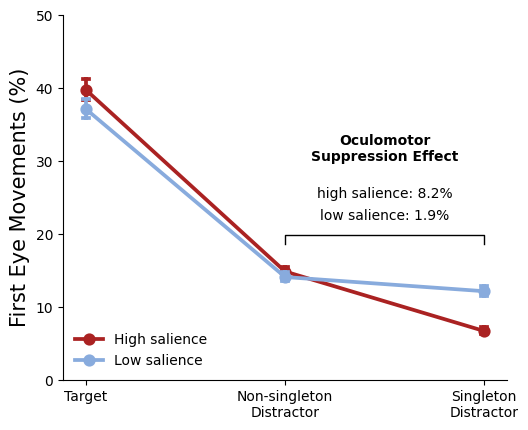

condition means over held-out subjects (%):
                       t    ns     s
High salience  39.799999  14.9   6.7
Low salience   37.099998  14.1  12.2 

2 x 2 repeated-measures ANOVA (unit: 66 held-out subjects)
         Source          SS  ddof1  ddof2          MS          F  p_unc  p_GG_corr    ng2  eps
       salience  365.201111      1     65  365.201111 158.150497    0.0        0.0 0.1932  1.0
           item 1684.665771      1     65 1684.665771 333.783813    0.0        0.0 0.5249  1.0
salience * item  637.722595      1     65  637.722595 184.979095    0.0        0.0 0.2949  1.0


In [54]:
# The REAL held-out trials are the HIGH-salience condition: every
# display is a green target with a RED singleton (opposite color).
# Counterfactual second pass, Han's design: re-sense the SAME
# trials with a TEAL singleton (near the target color = LOW
# salience), keep each subject's real selection history, and
# regenerate saccades for both passes. High pass: 9a's simulated
# saccades; low pass: drawn below.
A_LOW = torch.zeros_like(A_CH)
for d_, key in enumerate(keys):
    items_ = items_for(*key, sc="teal")
    ch = channel_maps(display_for(*key, sc="teal"), items_)
    for j_, (py_, px_) in enumerate(centers(key[0])):
        A_LOW[d_, j_] = ch[:, py_, px_].float()

with torch.no_grad():
    F_low, _ = model_F(w, raw_eta, A_LOW)
prob_low = torch.softmax(F_low.masked_fill(~tt["valid"], -1e9), 1)
gen3 = torch.Generator().manual_seed(2)
sim_low = torch.multinomial(prob_low[m], 1, generator=gen3).squeeze(1)
simch_low = torch.zeros(int(m.sum()), 6)
simch_low[torch.arange(int(m.sum())), sim_low] = 1

# the high pass IS 9a: same saccades, same per-subject frame -
# only the low pass is new
passes = {"High salience": frames["Model"],
          "Low salience": subject_rates(simch_low)}
long9b = rates_long(passes, "salience")

# suppression difference across salience = the salience x item-type
# interaction: 2 (high/low) x 2 (non-singleton/singleton)
# repeated-measures ANOVA across the held-out subjects
aov = pg.rm_anova(dv="rate", within=["salience", "item"], subject="si",
                  data=long9b[long9b["item"].isin(["ns", "s"])],
                  detailed=True)

fig9b, ax = plt.subplots(figsize=(5.4, 4.4))
ax = sns.pointplot(data=long9b, x="item", y="rate", hue="salience",
                   order=["t", "ns", "s"], hue_order=list(passes),
                   palette={"High salience": "#aa2222", "Low salience": "#88abdd"},
                   errorbar=("ci", 95), n_boot=10000, seed=0, capsize=0.03)
supp_ = {sal: p_["ns"].mean() - p_["s"].mean() for sal, p_ in passes.items()}
top = max(p_["ns"].mean() for p_ in passes.values()) + 5
ax.plot([1, 1, 2, 2], [top - 1.2, top, top, top - 1.2], "k-", lw=1)
ax.text(1.5, 30, "Oculomotor\nSuppression Effect", ha="center", fontsize=10, fontweight="bold")
ax.text(1.5, 25, f"high salience: {supp_['High salience']:.1f}%", ha="center", fontsize=10)
ax.text(1.5, 22, f"low salience: {supp_['Low salience']:.1f}%", ha="center", fontsize=10)
ax.set_xticks([0, 1, 2], ["Target", "Non-singleton\nDistractor", "Singleton\nDistractor"])
ax.set_xlabel(""); ax.set_ylabel("First Eye Movements (%)", fontsize=15)
ax.set_ylim(0, 50)
ax.legend(loc="lower left", frameon=False, title=None, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("condition means over held-out subjects (%):")
print(pd.DataFrame({sal: p_[["t", "ns", "s"]].mean()
                    for sal, p_ in passes.items()}).T.round(1).to_string(),
      "\n")
print(f"2 x 2 repeated-measures ANOVA (unit: "
      f"{long9b.si.nunique()} held-out subjects)")
print(aov.round(4).to_string(index=False))


The mechanism: `T` combines color and shape match in one signed
template map. A low-salience singleton carries weaker color mismatch;
a high-salience singleton carries stronger negative color evidence.
If it also has the wrong shape, the shape term makes it more negative
than a same-color circle. The learned `g_T` is constrained positive,
so this sign structure cannot flip during training.

### 9c. Target Statistical Learning

Here is the target-history analogue of the low-salience counterfactual in 9b. Keep the same
held-out displays and trained weights, but replay a synthetic block in
which the target is more likely to appear at one location. If the
leaky target trace is doing the right thing, the model should build a
spatial prior for that likely location and use it before the display
evidence is read out.


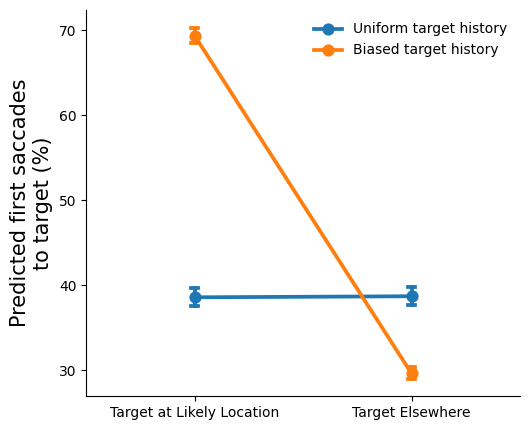

history                 target_location          
Biased target history   Target Elsewhere             29.600000
                        Target at Likely Location    69.400002
Uniform target history  Target Elsewhere             38.700001
                        Target at Likely Location    38.599998

2 x 2 repeated-measures ANOVA on target capture (unit: 66 held-out subjects)
                   Source           SS  ddof1  ddof2           MS            F  p_unc  p_GG_corr    ng2  eps
                  history  7781.788574      1     65  7781.788574  2138.550537    0.0        0.0 0.6586  1.0
          target_location 25915.302734      1     65 25915.302734  4711.384277    0.0        0.0 0.8653  1.0
history * target_location 26242.072266      1     65 26242.072266 10674.099609    0.0        0.0 0.8668  1.0

Counterfactual assumption: target appears at slot 2 on 70% of synthetic history trials.


In [55]:
LIKELY_LOC = 2       # 1-indexed slot: the statistically likely target location
P_LIKELY = 0.70      # counterfactual target-location probability

def synthetic_target_memories(p_likely, likely_loc=LIKELY_LOC, seed=3):
    """Replay a synthetic target-location sequence for every subject.

    The display evidence stays real. Only the between-trial target
    history is replaced by an environment where one location is more
    likely to contain the target.
    """
    S_, T_, L_ = tt["eT"].shape
    eta_T = torch.tensor(float(learned["eta_T"]))
    hT = torch.zeros(S_, L_)
    out = []
    gen = torch.Generator().manual_seed(seed)
    likely = likely_loc - 1
    for t in range(T_):
        out.append(hT.clone())
        loc = torch.randint(0, L_ - 1, (S_,), generator=gen)
        loc = loc + (loc >= likely).long()
        choose_likely = torch.rand(S_, generator=gen) < p_likely
        loc[choose_likely] = likely
        e = torch.zeros(S_, L_)
        e[torch.arange(S_), loc] = 1.0
        hT = (1 - eta_T) * hT + eta_T * e
    return torch.stack(out, 1)

def probabilities_with_target_memory(memT_):
    Ad = A_CH[didx]
    g_T = float(learned["g_T"])
    stimulus = learned["alpha_P"]*Ad[..., 0] + g_T*Ad[..., 1]
    hT = memT_[tt["si"], tt["ti"]]
    F_ = stimulus + learned["beta_T"] * hT
    return torch.softmax(F_.masked_fill(~tt["valid"], -1e9), 1), F_

mem_uniform = synthetic_target_memories(1/6, seed=4)
mem_biased = synthetic_target_memories(P_LIKELY, seed=4)
prob_uniform, _ = probabilities_with_target_memory(mem_uniform)
prob_biased, _ = probabilities_with_target_memory(mem_biased)

held = test & first
targ_at_likely = held & torch.tensor(sacc.targLoc.values == LIKELY_LOC)
targ_elsewhere = held & torch.tensor(sacc.targLoc.values != LIKELY_LOC)

def subject_target_capture(prob_, mask_):
    d_ = pd.DataFrame(dict(
        si=tt["si"][mask_].numpy(),
        target=(prob_[mask_] * isT[mask_]).sum(1).numpy() * 100))
    return d_.groupby("si").mean()

frames9c = {}
for label, prob_ in [("Uniform target history", prob_uniform),
                     ("Biased target history", prob_biased)]:
    frames9c[(label, "Target at Likely Location")] = subject_target_capture(prob_, targ_at_likely)
    frames9c[(label, "Target Elsewhere")] = subject_target_capture(prob_, targ_elsewhere)

long_target = pd.concat([
    fr.reset_index().assign(history=hist, target_location=where)
    for (hist, where), fr in frames9c.items()
])

fig9c, ax = plt.subplots(figsize=(5.4, 4.4))
ax = sns.pointplot(data=long_target, x="target_location", y="target", hue="history",
                   order=["Target at Likely Location", "Target Elsewhere"],
                   hue_order=["Uniform target history", "Biased target history"],
                   errorbar=("ci", 95), n_boot=10000, seed=0, capsize=0.03)
ax.set_xlabel("")
ax.set_ylabel("Predicted first saccades\nto target (%)", fontsize=15)
ax.legend(frameon=False, title=None, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

summary9c = long_target.groupby(["history", "target_location"]).target.mean().round(1)
print(summary9c.to_string())

aov9c = pg.rm_anova(dv="target", within=["history", "target_location"],
                     subject="si", data=long_target, detailed=True)
print(f"\n2 x 2 repeated-measures ANOVA on target capture "
      f"(unit: {long_target.si.nunique()} held-out subjects)")
print(aov9c.round(4).to_string(index=False))

print(f"\nCounterfactual assumption: target appears at slot {LIKELY_LOC} "
      f"on {P_LIKELY:.0%} of synthetic history trials.")


### 9d. Combined Evaluation Figure

This cell redraws the three §9 results into one figure for presentation.


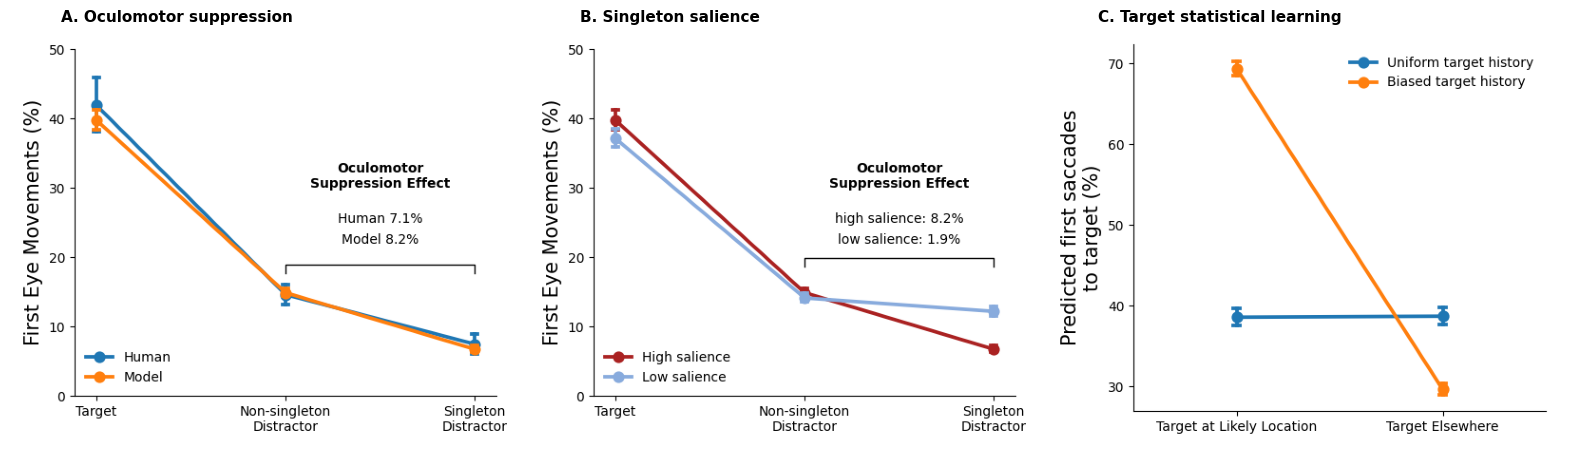

In [63]:
def figure_image(fig):
    fig.canvas.draw()
    return np.asarray(fig.canvas.buffer_rgba())

fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.6))
for ax, panel, title, src_fig in zip(
        axes,
        ["A", "B", "C"],
        ["Oculomotor suppression", "Singleton salience", "Target statistical learning"],
        [fig9a, fig9b, fig9c]):
    ax.imshow(figure_image(src_fig))
    ax.set_axis_off()
    ax.text(0.1, 1.05, f"{panel}. {title}", transform=ax.transAxes,
            ha="left", va="top", fontsize=11, fontweight="bold")
plt.tight_layout(w_pad=0.4)
plt.show()


## 10. The spatial prior over a span of trials

Section 5 used made-up history; here are the REAL trained target
memories for one held-out person across a span of consecutive trials.
Before each display appears, the item-level prior `beta_T*h_T` already
tilts toward locations where the target has recently appeared. For
display purposes only, each item-level prior is painted into that
trial's actual item-shape footprint.

The small panels show a trial span; the bar chart summarizes the same
prior across all held-out trials.


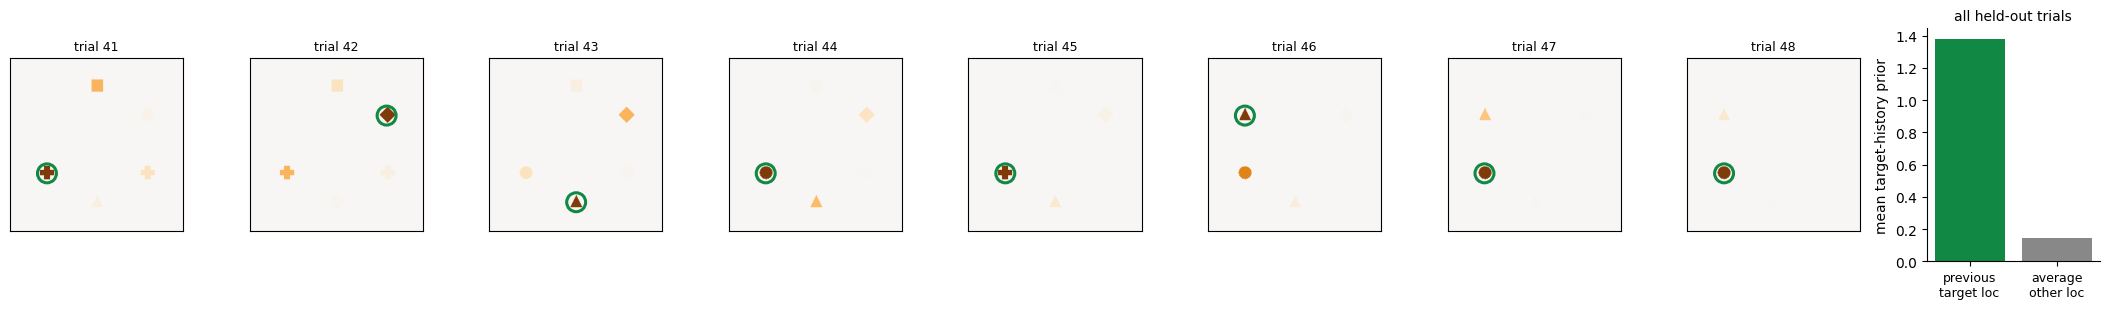

prior at previous target location: +1.376  vs other locations: +0.142


In [57]:
si_np = tt["si"].numpy(); ti_np = tt["ti"].numpy()
subj = int(np.unique(si_np[test.numpy()])[0])       # one held-out person
trial_pool = np.sort(ti_np[(si_np == subj)])
SPAN_START = 40
SPAN_LEN = 8
trials = trial_pool[SPAN_START:SPAN_START + SPAN_LEN]

with torch.no_grad():
    ncols = len(trials)
    fig, axes = plt.subplots(1, ncols + 1, figsize=(2.25*ncols + 3.2, 3.2))
    for ax, t in zip(axes[:ncols], trials):
        hT_t = memT[subj, t].numpy()
        prior_t = learned["beta_T"] * hT_t
        row = sacc.iloc[np.where((si_np == subj) & (ti_np == t))[0][0]]
        display_items = items_for(int(row.setsize), int(row.targLoc), int(row.singLoc))
        pm = selection_history_map(prior_t, display_items)
        v = max(np.abs(pm).max(), 1e-9)
        ax.imshow(pm, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
        prev = int(tt["eT"][subj, t-1].argmax()) if t > 0 and tt["eT"][subj, t-1].sum() > 0 else None
        if prev is not None and prev < int(row.setsize):
            ipos, _ = item_positions(int(row.setsize))
            px, py = (ipos[prev][0]+0.75)/1.5*IMG, (ipos[prev][1]+0.75)/1.5*IMG
            ax.add_patch(plt.Circle((px, py), 14, fill=False,
                                    ec="#118844", lw=2.2))
        ax.set_title(f"trial {int(t)}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    prior_slots = learned["beta_T"] * memT
    at_prev, at_other = [], []
    for s in np.unique(si_np[test.numpy()]):
        eT_s = tt["eT"][int(s)]
        T_ = int(ti_np[si_np == int(s)].max()) + 1
        for t in range(1, T_):
            if eT_s[t-1].sum() == 0:
                continue
            prev = int(eT_s[t-1].argmax())
            vals = prior_slots[int(s), t].numpy()
            at_prev.append(vals[prev])
            at_other.append(np.delete(vals, prev).mean())
    axes[-1].bar([0, 1], [np.mean(at_prev), np.mean(at_other)],
                 color=["#118844", "#888888"])
    axes[-1].set_xticks([0, 1])
    axes[-1].set_xticklabels(["previous\ntarget loc", "average\nother loc"],
                             fontsize=9)
    axes[-1].set_ylabel("mean target-history prior")
    axes[-1].set_title("all held-out trials", fontsize=10)
    axes[-1].spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

print(f"prior at previous target location: {np.mean(at_prev):+.3f}  "
      f"vs other locations: {np.mean(at_other):+.3f}")


## Recap

| The model receives | It returns |
| --- | --- |
| item evidence, a goal, and target history | a probability per item |

We laid out the item-based structure (§1) and displays (§2), introduced sensory evidence (§3), built unified green-circle template evidence (§4), built the leaky target-history trace (§5), showed how the ingredients combine (§6), used `priority_map` -> `predict_saccade` as a visual worked example (§7), trained the four parameters on all real first saccades through an exact item cache (§8), evaluated on held-out people (§9), tested oculomotor suppression, the salience gradient under a counterfactual low-salience singleton, and target statistical learning (§9a-c), and then watched the spatial prior evolve across a span of trials (§10).

More: `RESULTS.md` (the results ledger) and `docs/priority_field_visual_search_model.md` (the theory).
